In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader


In [4]:
# Data augmentation
transform = transforms.Compose([   
    transforms.RandomResizedCrop(227, scale=(0.8, 1.0)), # rezize down and random crop the 512x512 for 227x227 AlexNet input
    transforms.RandomHorizontalFlip(0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # color aug for food
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([  
    transforms.Resize(256),
    transforms.CenterCrop(227), # better for testing 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_set = torchvision.datasets.Food101(root='./data', split='train', download=True, transform=transform)
test_set = torchvision.datasets.Food101(root='./data', split='test', download=True, transform=test_transform)

train_loader = DataLoader(train_set, batch_size=256,
                           shuffle=True, 
                           num_workers=6,
                           pin_memory=True, # faster cpu-gpu transfer
                           persistent_workers=True # keeps cpu alive, faster
                           )

test_loader = DataLoader(test_set, batch_size=256, shuffle=False, num_workers=6, pin_memory=True, persistent_workers=True)

In [5]:

class AlexNet(nn.Module):  # Modern AlexNet (cuz batchnorm/dropout)
    def __init__(self, num_classes=10): 
        super().__init__()

        self.conv1 = nn.Conv2d(3,96,stride=4,kernel_size=11) 
        self.norm1 = nn.BatchNorm2d(96)
        #pool.   => 55x55x96 size now
        self.conv2 = nn.Conv2d(96, 256, kernel_size=5, padding=2)
        self.norm2 = nn.BatchNorm2d(256)
        #pool    => 27x27x256 size now
        self.conv3 = nn.Conv2d(256, 384, kernel_size=3, padding=1)
        self.norm3 = nn.BatchNorm2d(384)

        self.conv4 = nn.Conv2d(384, 384, kernel_size=3, padding=1)
        self.norm4 = nn.BatchNorm2d(384)

        self.conv5 = nn.Conv2d(384, 256, kernel_size=3, padding=1)
        self.norm5 = nn.BatchNorm2d(256)
        #pool    => 6x6x256 size now

        self.maxpool = nn.MaxPool2d(3,stride=2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

        # flatten before
        self.fc1 = nn.Linear(6*6*256, 4096)
        # relu dropout
        self.fc2 = nn.Linear(4096, 4096) # not half cuz of dropout, dropout *0 and doesnt remove 
        # relu dropout
        self.fc3 = nn.Linear(4096, num_classes) # cuz cifar 10 has 10 classes

        

    def forward(self, x):
        out = self.maxpool(self.relu(self.norm1(self.conv1(x)))) # we put norm before relu cuz it normalizez, even though it acts as regu too.
        out = self.maxpool(self.relu(self.norm2(self.conv2(out))))
        out = self.relu(self.norm3(self.conv3(out)))
        out = self.relu(self.norm4(self.conv4(out)))
        out = self.maxpool(self.relu(self.norm5(self.conv5(out))))

        out = out.view(out.size(0), -1)  #out/x.size(0) == batch size.   view makes this 2D instead of 4D (batch, c, h, w)

        out = self.dropout(self.relu(self.fc1(out))) # we put dropout after relu, cuz unlike batchnorm, it turns completly off when model.eval + math messesup if we do it before relu.
        out = self.dropout(self.relu(self.fc2(out)))
        out = self.fc3(out)
        return out

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AlexNet(num_classes=101).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0003)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1) # multiply lr by 0.1 each 30 epoch

In [ ]:
# this block instead of the other commented one just to utilize my rtx 4070 super tensor cores for the mixed precision
torch.backends.cudnn.benchmark = True  # cuz images are fixed size, choose best path once
scaler = torch.amp.GradScaler('cuda')  # scale to use mixed precision safely 
total = len(train_set)
num_epochs = 100

for epoch in range(num_epochs):
    model.train()
    running_loss, correct = 0.0, 0

    for images, labels in train_loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)  # non_blocking=True is needed for the pin_memory=True in data loader
        
        
        optimizer.zero_grad()

        # forward pass with tensor cores
        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}, Accuracy: {100 * correct / total:.2f}%")
    scheduler.step()


"""
num_epochs = 50
total = len(train_set)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss:.4f}, Accuracy: {100 * correct / total:.2f}%")
    scheduler.step()
"""



Epoch [1/100], Loss: 4.3615, Accuracy: 4.30%
Epoch [2/100], Loss: 3.9666, Accuracy: 9.73%
Epoch [3/100], Loss: 3.7066, Accuracy: 13.69%
Epoch [4/100], Loss: 3.4967, Accuracy: 17.45%
Epoch [5/100], Loss: 3.3331, Accuracy: 20.49%
Epoch [6/100], Loss: 3.1984, Accuracy: 23.05%
Epoch [7/100], Loss: 3.0807, Accuracy: 25.38%
Epoch [8/100], Loss: 2.9610, Accuracy: 27.72%
Epoch [9/100], Loss: 2.8656, Accuracy: 29.58%
Epoch [10/100], Loss: 2.7716, Accuracy: 31.49%
Epoch [11/100], Loss: 2.6891, Accuracy: 33.24%
Epoch [12/100], Loss: 2.6065, Accuracy: 35.09%
Epoch [13/100], Loss: 2.5194, Accuracy: 36.94%
Epoch [14/100], Loss: 2.4570, Accuracy: 38.09%
Epoch [15/100], Loss: 2.3995, Accuracy: 39.54%
Epoch [16/100], Loss: 2.3242, Accuracy: 41.10%
Epoch [17/100], Loss: 2.2735, Accuracy: 42.09%
Epoch [18/100], Loss: 2.2192, Accuracy: 43.44%
Epoch [19/100], Loss: 2.1611, Accuracy: 44.65%
Epoch [20/100], Loss: 2.1182, Accuracy: 45.43%
Epoch [21/100], Loss: 2.0601, Accuracy: 46.71%
Epoch [22/100], Loss: 2.

KeyboardInterrupt: 

In [ ]:
# I STOPED AT EPOCH 70

In [ ]:
model.eval()
correct = 0
total = len(test_set)

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        correct += (predicted == labels).sum().item()

print(f'Test Accuracy: {100 * correct / total:.2f}%')


Test Accuracy: 60.57%


In [ ]:
torch.save({
    'epoch': num_epochs,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': running_loss/len(train_loader),
}, "checkpoint.pth")

In [6]:
# load model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AlexNet(num_classes=101).to(device)

checkpoint = torch.load("checkpoint.pth", map_location=device)

model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

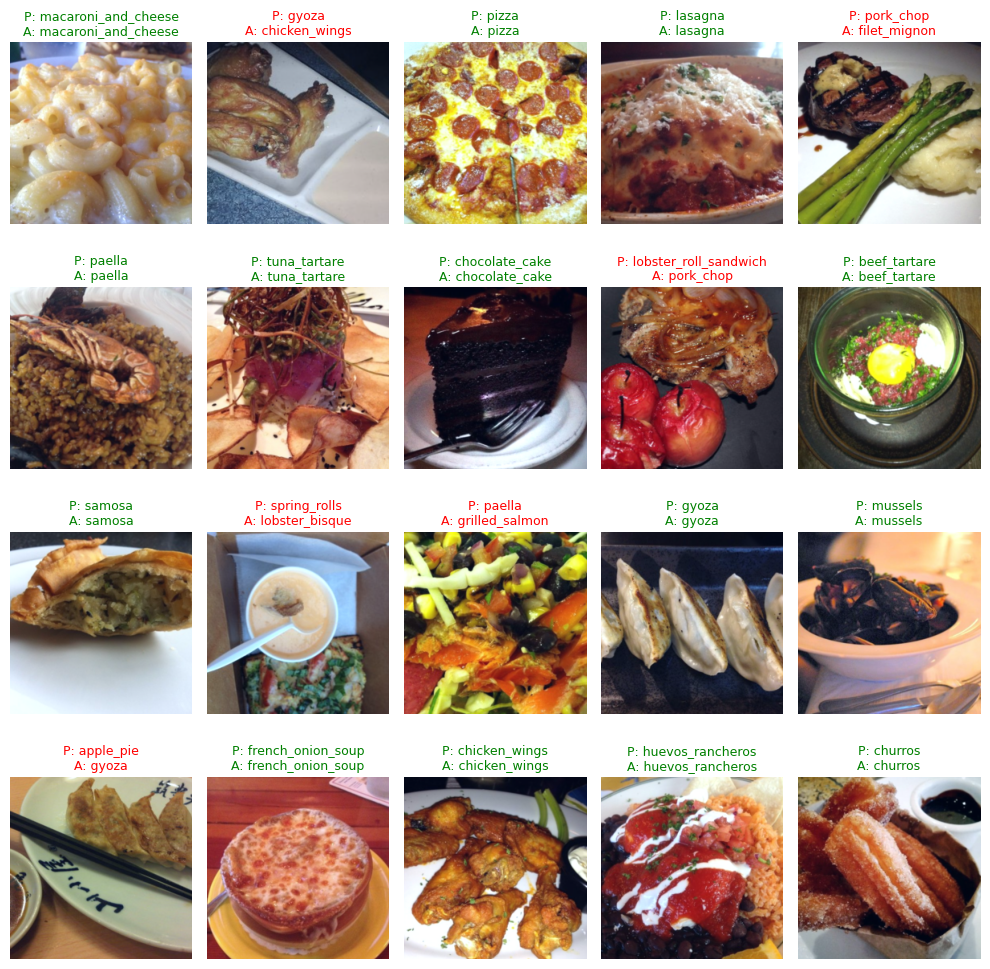

In [ ]:
import random

def visualize_random_30_results(model, dataset, dataset_classes):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    indices = random.sample(range(len(dataset)), 20)
    
    plt.figure(figsize=(10, 15))
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            # 1. Get image and label
            img_tensor, label = dataset[idx]
            
            # 2. Get prediction (Fixed the 'outputs' typo here)
            # We unsqueeze to add the batch dimension: [3, 224, 224] -> [1, 3, 224, 224]
            output = model(img_tensor.unsqueeze(0).to(device))
            _, predicted = torch.max(output, 1) # Changed 'outputs' to 'output'
            
            plt.subplot(6, 5, i+1)
            
            # 3. Un-normalize for display
            # We move back to CPU and change dimensions for Matplotlib
            img_display = img_tensor.permute(1, 2, 0).cpu().numpy()
            # Standard Food-101 / ImageNet un-norm
            img_display = img_display * 0.229 + 0.485 
            
            plt.imshow(np.clip(img_display, 0, 1))
            
            p_name = dataset_classes[predicted.item()]
            a_name = dataset_classes[label]
            
            color = 'green' if p_name == a_name else 'red'
            plt.title(f"P: {p_name}\nA: {a_name}", color=color, fontsize=9)
            plt.axis('off')
            
    plt.tight_layout()
    plt.show()

# Run it
visualize_random_30_results(model, test_loader.dataset, test_loader.dataset.classes)